# Multidimensional Scaling (MDS) — Jeu de données Eurodist
Ce notebook applique le **MDS (Multidimensional Scaling)** sur le jeu de données `eurodist` (distances routières entre villes européennes).

L'approche suit la structure rigoureuse suivante :
1. **Chargement et prétraitement** des données.
2. **Optimisation des hyperparamètres** (n_init, max_iter) via **Optuna** en minimisant le *Stress*.
3. **Entraînement final** et **Visualisation** de la carte reconstruite.
4. **Évaluation** via le Stress et la corrélation des distances.

In [8]:
import pandas as pd
import numpy as np
from sklearn.manifold import MDS
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from scipy.spatial.distance import pdist, squareform

sns.set(style="whitegrid")

In [9]:
# Chargement du dataset eurodist
url = "https://github.com/neurospin/pystatsml/raw/master/datasets/eurodist.csv"
df = pd.read_csv(url)

cities = df["city"].values
D = np.array(df.iloc[:, 1:])   # Matrice de distances symétrique

print(f"Jeu de données chargé : {len(cities)} villes.")
df.head()

Jeu de données chargé : 21 villes.


,city,Athens,Barcelona,Brussels,Calais,Cherbourg,Cologne,Copenhagen,Geneva,Gibraltar,...,Lisbon,Lyons,Madrid,Marseilles,Milan,Munich,Paris,Rome,Stockholm,Vienna
0,Athens,0,3313,2963,3175,3339,2762,3276,2610,4485,...,4532,2753,3949,2865,2282,2179,3000,817,3927,1991
1,Barcelona,3313,0,1318,1326,1294,1498,2218,803,1172,...,1305,645,636,521,1014,1365,1033,1460,2868,1802
2,Brussels,2963,1318,0,204,583,206,966,677,2256,...,2084,690,1558,1011,925,747,285,1511,1616,1175
3,Calais,3175,1326,204,0,460,409,1136,747,2224,...,2052,739,1550,1059,1077,977,280,1662,1786,1381
4,Cherbourg,3339,1294,583,460,0,785,1545,853,2047,...,1827,789,1347,1101,1209,1160,340,1794,2196,1588


In [10]:
def objective(trial):
    # Hyperparamètres à optimiser
    n_init = trial.suggest_int("n_init", 4, 20)
    max_iter = trial.suggest_int("max_iter", 300, 1000)
    eps = trial.suggest_float("eps", 1e-4, 1e-2, log=True)
    
    # MDS
    mds = MDS(
        n_components=2, 
        dissimilarity='precomputed', 
        n_init=n_init, 
        max_iter=max_iter, 
        eps=eps, 
        random_state=42
    )
    
    mds.fit(D)
    return mds.stress_

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Meilleurs paramètres :", study.best_params)
print("Meilleur Stress :", study.best_value)

[I 2026-05-05 00:21:00,944] A new study created in memory with name: no-name-35cfe4dd-64ab-461e-ac0c-e680a6e7962f
[I 2026-05-05 00:21:02,399] Trial 0 finished with value: 3356500.239470101 and parameters: {'n_init': 15, 'max_iter': 398, 'eps': 0.00012510604565196066}. Best is trial 0 with value: 3356500.239470101.
[I 2026-05-05 00:21:03,447] Trial 1 finished with value: 3356572.718639156 and parameters: {'n_init': 20, 'max_iter': 546, 'eps': 0.0013657479326041474}. Best is trial 0 with value: 3356500.239470101.
[I 2026-05-05 00:21:04,118] Trial 2 finished with value: 3356581.6523545934 and parameters: {'n_init': 12, 'max_iter': 859, 'eps': 0.0014422746955563609}. Best is trial 0 with value: 3356500.239470101.
[I 2026-05-05 00:21:04,283] Trial 3 finished with value: 3356509.236674767 and parameters: {'n_init': 4, 'max_iter': 932, 'eps': 0.0002909618649318386}. Best is trial 0 with value: 3356500.239470101.
[I 2026-05-05 00:21:05,134] Trial 4 finished with value: 3356554.2079773815 and p

Meilleurs paramètres : {'n_init': 12, 'max_iter': 685, 'eps': 0.00010190830622201664}
Meilleur Stress : 3356499.3329507867


In [11]:
# Entraînement final avec les meilleurs paramètres
best_mds = MDS(
    n_components=2, 
    dissimilarity='precomputed', 
    random_state=42,
    **study.best_params
)

embedding = best_mds.fit_transform(D)

# Évaluation : Stress final
stress = best_mds.stress_
print(f"Stress final : {stress:.2f}")

Stress final : 3356499.33


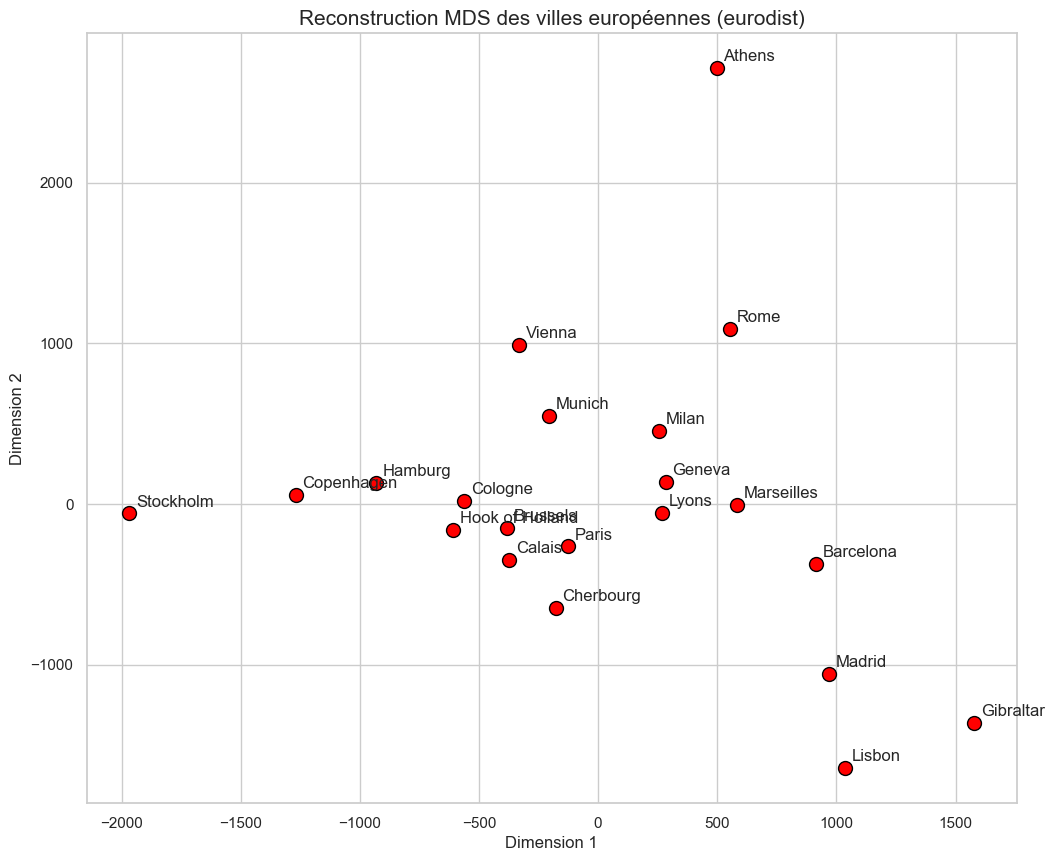

In [12]:
# Visualisation de la carte
plt.figure(figsize=(12, 10))

x_coords = embedding[:, 0]
y_coords = embedding[:, 1]

# Inversion de l'axe Y pour avoir le Nord en haut
y_coords = -y_coords 

plt.scatter(x_coords, y_coords, color='red', s=100, edgecolors='black')

for i, city in enumerate(cities):
    plt.annotate(city, (x_coords[i], y_coords[i]), xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.title("Reconstruction MDS des villes européennes (eurodist)", fontsize=15)
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

Corrélation entre distances réelles et projetées : 0.9900


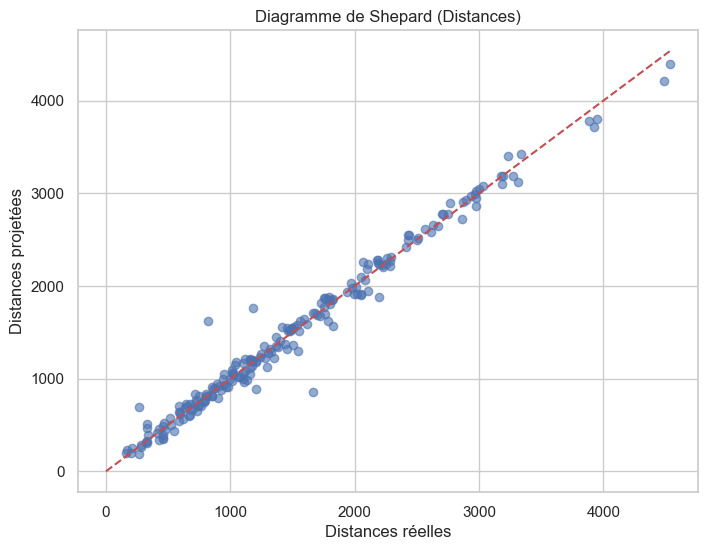

In [13]:
# Évaluation qualitative : Corrélation entre distances originales et projetées
dist_original = D[np.triu_indices(len(cities), k=1)]
dist_embedded = squareform(pdist(embedding))[np.triu_indices(len(cities), k=1)]

correlation = np.corrcoef(dist_original, dist_embedded)[0, 1]
print(f"Corrélation entre distances réelles et projetées : {correlation:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(dist_original, dist_embedded, alpha=0.6)
plt.plot([0, dist_original.max()], [0, dist_original.max()], 'r--')
plt.xlabel("Distances réelles")
plt.ylabel("Distances projetées")
plt.title("Diagramme de Shepard (Distances)")
plt.show()